#### Se analizará un conjunto de datos correspondiente a ventas de tiendas en facebook live de thailandia extraídos de la siguiente url:
- **https://archive.ics.uci.edu/ml/datasets/Facebook+Live+Sellers+in+Thailand**

In [13]:
import os
import sys

carpeta_actual = os.getcwd()
ruta_raiz = os.path.dirname(carpeta_actual)
print(ruta_raiz)
# Añade la raíz al buscador de Python si no está ahí
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

# Ahora ya puedes importar tus funciones
from utilidades.mis_funciones import *

c:\Users\mbang\Desktop\GitMikis\Proyecto2


In [23]:
# Cargar el primer archivo
ruta_archivo = f"{ruta_raiz}/datasets/Live_20210128.csv"
df1 = cargar_archivo_drive(ruta_archivo)
analisis_inicial(df1)

Tamaño: (7050, 16)

Primeras 5 filas del DataFrame:
   status_id status_type status_published  num_reactions  num_comments  \
0          1       video   4/22/2018 6:00            529           512   
1          2       photo  4/21/2018 22:45            150             0   
2          3       video   4/21/2018 6:17            227           236   
3          4       photo   4/21/2018 2:29            111             0   
4          5       photo   4/18/2018 3:22            213             0   

   num_shares  num_likes  num_loves  num_wows  num_hahas  num_sads  \
0         262        432         92         3          1         1   
1           0        150          0         0          0         0   
2          57        204         21         1          1         0   
3           0        111          0         0          0         0   
4           0        204          9         0          0         0   

   num_angrys  Column1  Column2  Column3  Column4  
0           0      NaN      Na

In [16]:
# Primero, voy a limpiar un poco este df1, sacando las columnas que están 100% nulas ya que no
# existe algún indicio a qué hacen referencia.
df1_clean = df1.drop(columns=['Column1', 'Column2', 'Column3', 'Column4'])
# Ahora, convierto la columna 'status_published' a formato de fecha y hora
df1_clean['status_published'] = pd.to_datetime(df1_clean['status_published'])

display(df1_clean.head())
df1_clean['status_type'].value_counts()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0


status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64

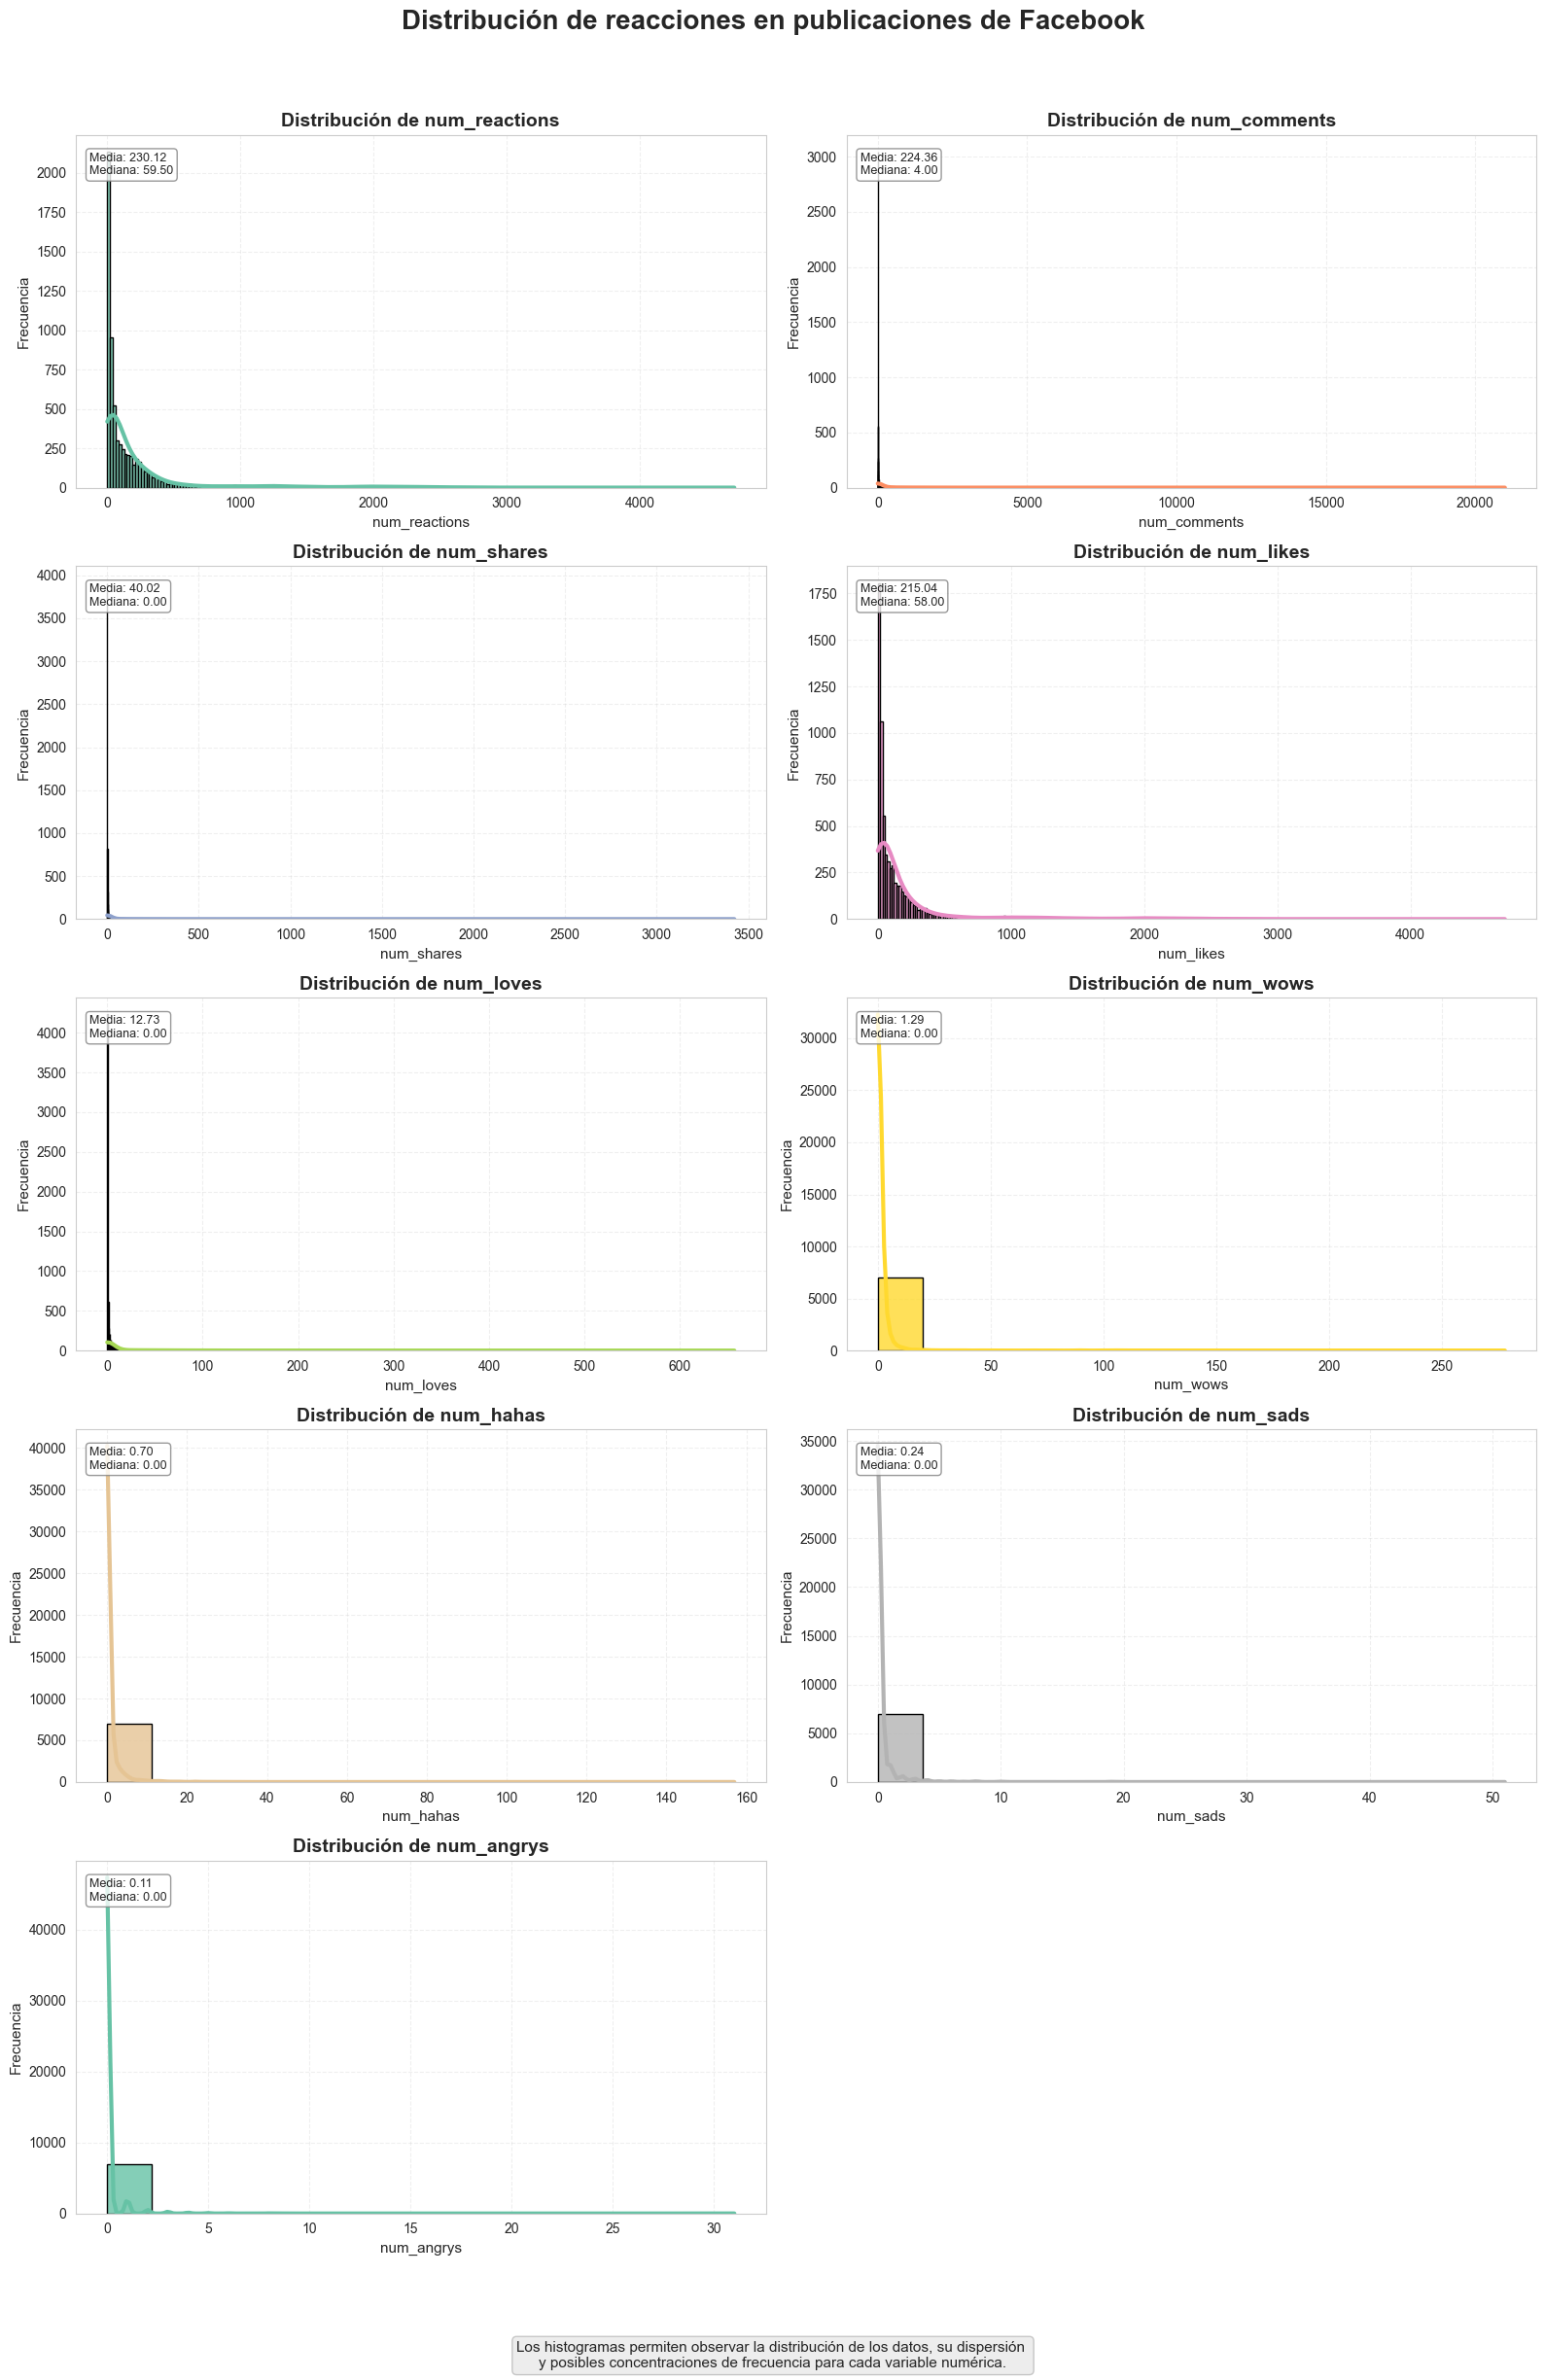

In [17]:
# Voy a quitar la columna status_id porque no me interesa graficar un id, considero que no es relevante.
df1_hist = df1_clean.drop(columns=['status_id'])
graficar_histogramas(df1_hist, "Distribución de reacciones en publicaciones de Facebook")

### Ahora veré qué tipo de publicaciones son las más populares.

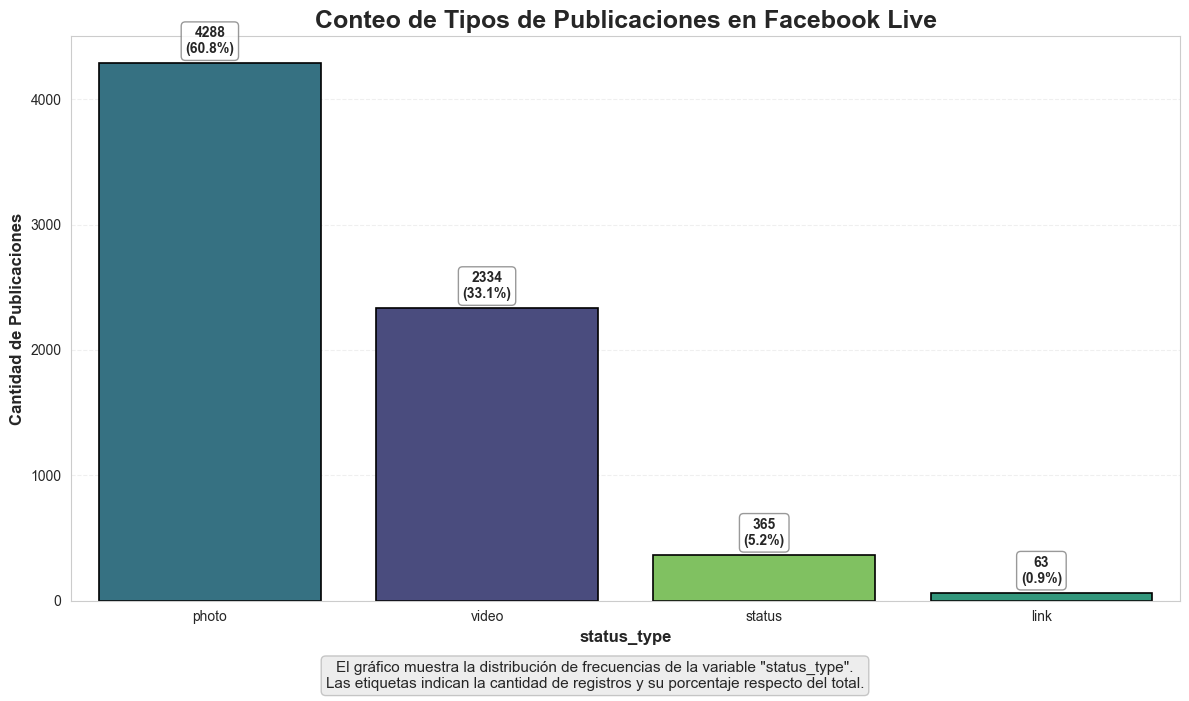

In [18]:
titulo = 'Conteo de Tipos de Publicaciones en Facebook Live'
etiq_y = 'Cantidad de Publicaciones'
etiq_x = 'Tipo de Publicación'
grafico_conteo(df1_clean, 'status_type',titulo,y_label=etiq_y,x_label=etiq_x)

## Observar valores outliers con un gráfico

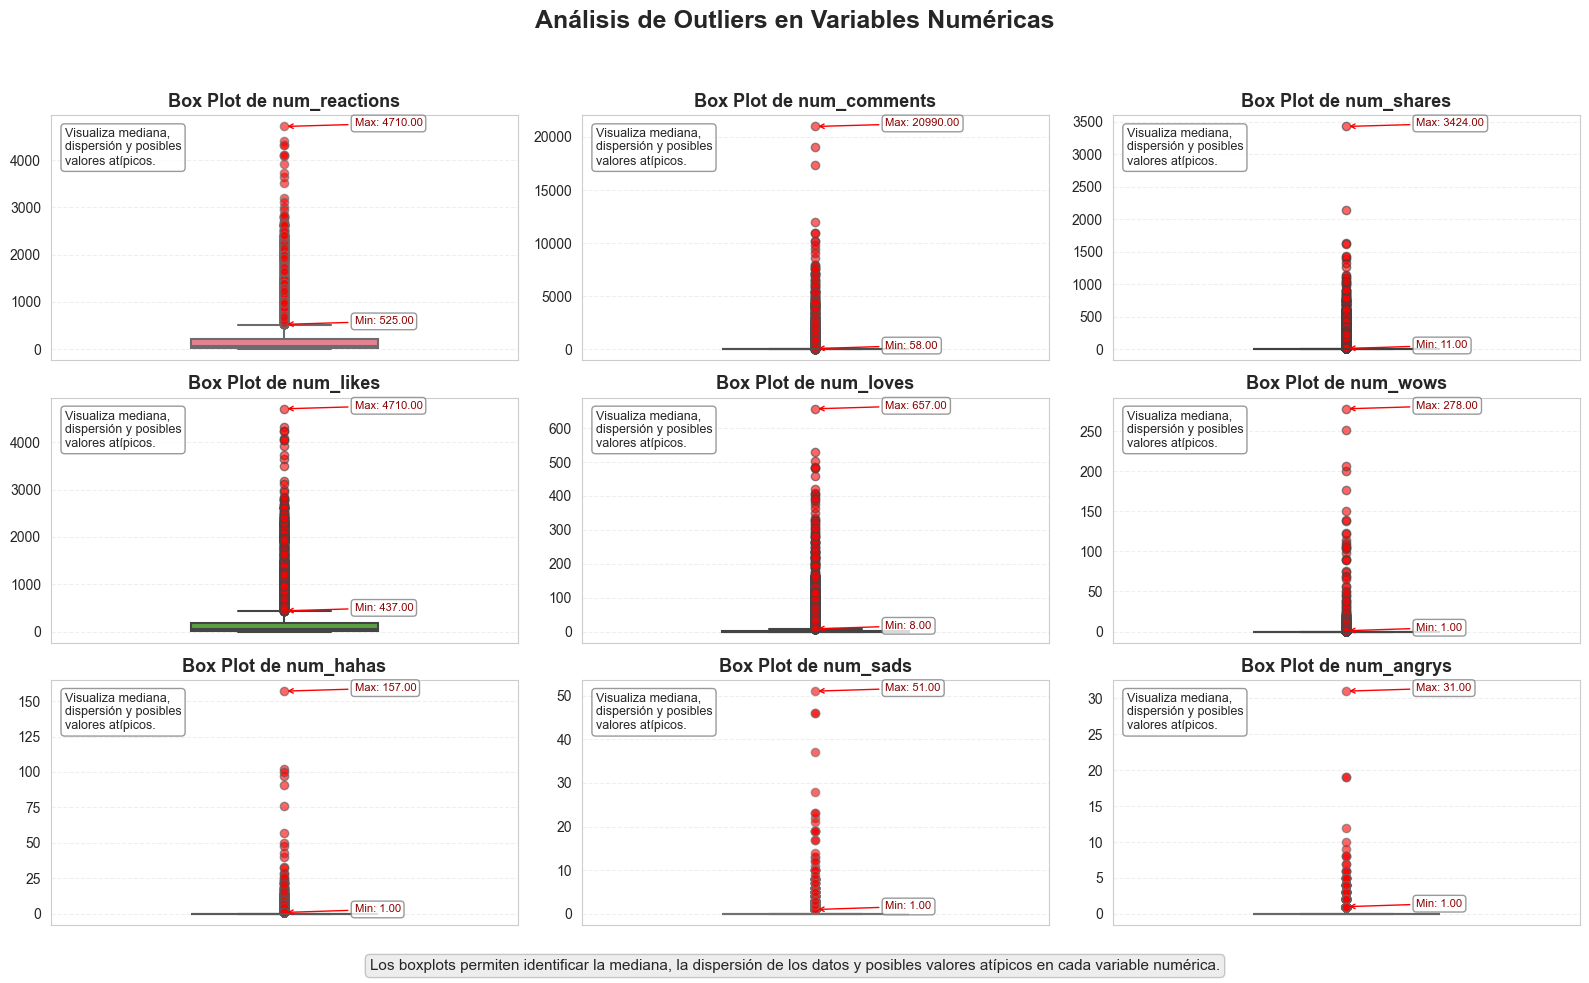

In [19]:
# A continuación se graficará el boxplots para observar valores outliers
# Utilizaré el df al que le extraje el id
col_num_df1 = df1_hist.select_dtypes(include=[np.number]).columns.tolist()
boxplots(df1_hist, col_num_df1)

### Finalmente observar la correlación entre las variables

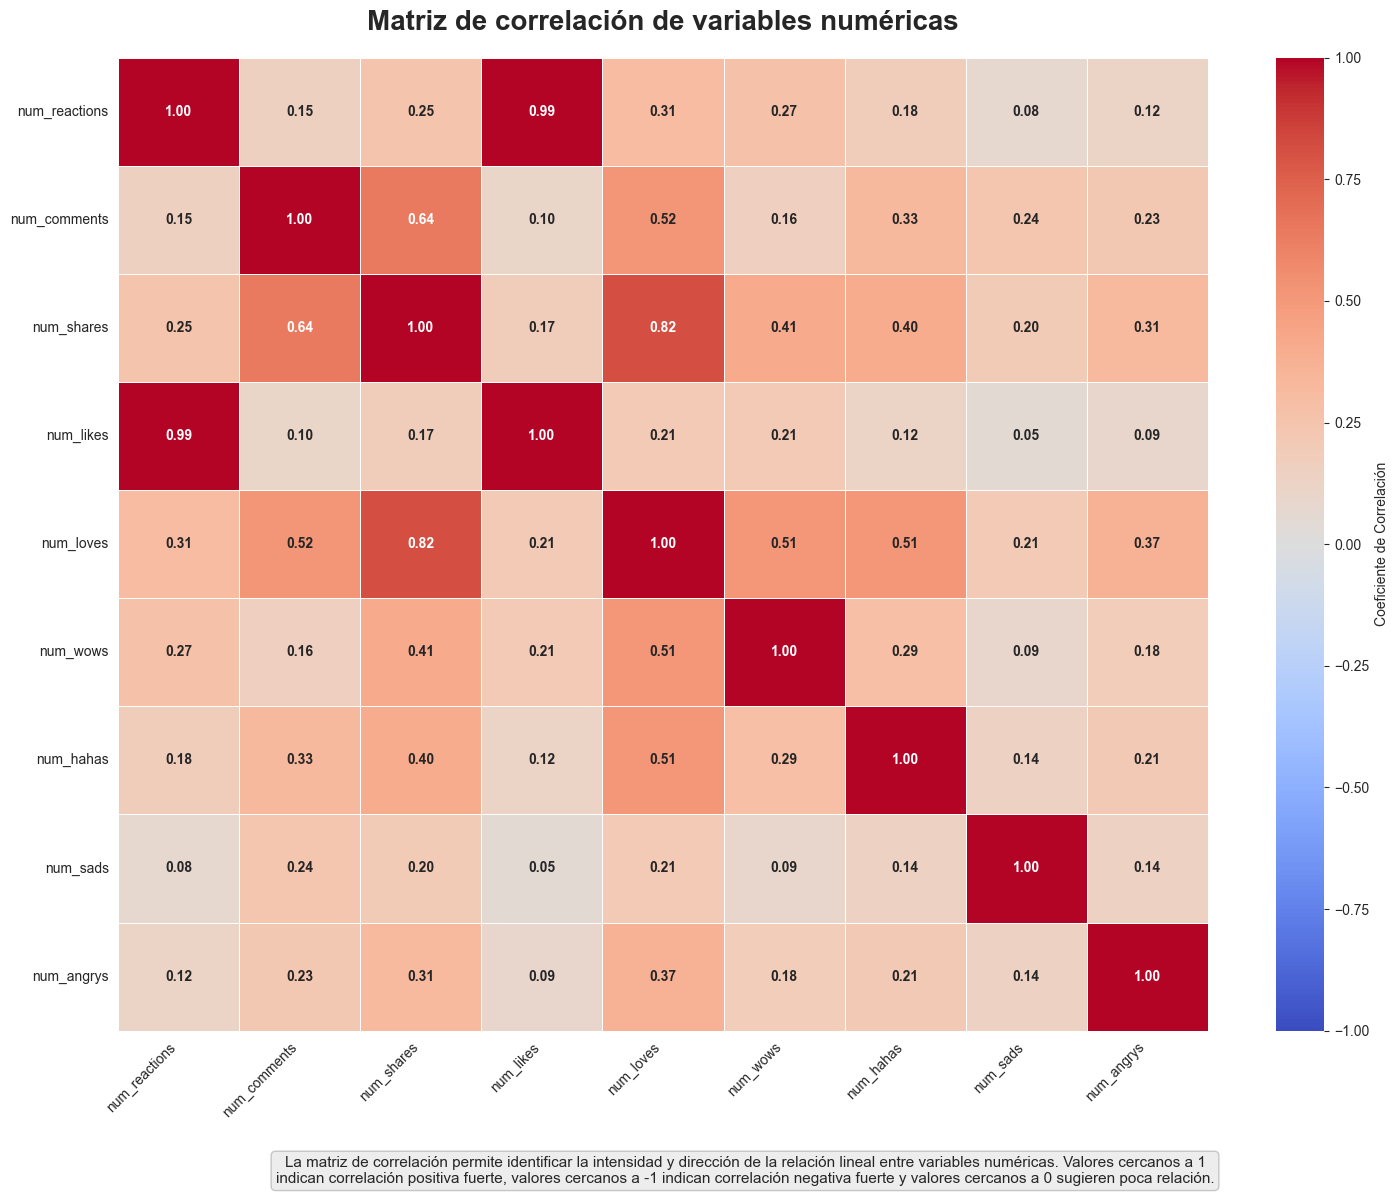

In [20]:
# matriz de correlación correspondiente
matriz_corr(df1_hist, col_num_df1)

In [22]:
# Ahora verificaré los outliers de forma manual
num_cols = df1_hist.select_dtypes(include=[np.number]).columns
print("Outliers detectados por el método IQR:")
for col in num_cols:
    outliers = detecta_atipicos_iqr(df1_clean, col)
    if not outliers.empty:
        print(f"\nColumna: {col}")
        display(outliers[[col]])
    else:
        print(f"\nColumna: {col}: No se detectaron outliers según el método IQR.")

Outliers detectados por el método IQR:

Columna: num_reactions


,num_reactions
0,529
92,675
93,737
94,572
99,1493
...,...
6810,558
6814,570
6835,607
6995,685



Columna: num_comments


,num_comments
0,512
2,236
6,614
7,453
15,100
...,...
6974,5404
6977,4432
6978,4472
6985,60



Columna: num_shares


...

,num_hahas
0,1
2,1
6,2
7,1
15,5
...,...
7002,1
7004,1
7011,21
7014,1



Columna: num_sads


,num_sads
0,1
17,1
45,1
49,3
54,1
...,...
6958,2
6964,1
6974,2
6977,5



Columna: num_angrys


,num_angrys
6,3
7,1
42,1
45,4
47,1
...,...
6927,1
6932,1
6955,1
6964,1


## Interpretación de Outliers IQR

### Los outliers detectados por el método IQR en las columnas de reacciones no suelen ser errores de entrada de datos en este contexto. Más bien, son valores extremos pero legítimos que representan publicaciones con una interacción alta. En redes sociales, es común tener una distribución así. Un pequeño porcentaje de contenido capta la mayor parte de la atención, mientras que la mayoría pasa desapercibido. La presencia de tantos valores extremos pueden tener un impacto importante en los modelos. Existen modelos que asumen normalidad en los datos o que son sensibles a los valores extremos (como la regresión lineal simple) que podrían verse afectados. Otros modelos más robustos a outliers (como los basados en árboles) podrían manejar mejor esta situación.
### **La decisión de cómo tratar estos outliers dependerá del problema específico que quiera resolver con este dataset. Por ahora, es clave entender que existen y que representan la dinámica natural de las interacciones en Facebook Live.**

## Hallazgos del EDA para df1 (Facebook Live Sellers)

Con los gráficos que hice y la exploración, se puede sacar varias conclusiones del dataset de ventas en Facebook Live:

### Observaciones generales:

* Se tiene 7050 registros y 12 columnas (después de eliminar las columnas Column1 a Column4 que estaban vacías).
* Después de la limpieza, no tengo valores nulos en ninguna de las columnas que me interesan, lo que simplifica harto la pega inicial.
* No se encontraron filas completamente duplicadas, lo que es un buen indicio de la calidad inicial del dataset.
* La columna status_published la convertí a formato datetime. Las columnas de num_reactions, num_comments, num_shares, etc., son numéricas, como se espera

### Análisis de visualizaciones:
* En la mayoría de los gráficos de distribución de reacciones, se observa una asimetría muy pronunciada hacia la derecha. Esto significa que la gran mayoría de las publicaciones tienen pocas reacciones, y solo unas pocas publicaciones reciben una cantidad excepcionalmente alta de interacciones. Esto es típico en redes sociales y me indica que hay publicaciones virales que destacan del resto.
* Los num_likes son la reacción más frecuente, seguido por num_comments. Otras reacciones como num_sads o num_angrys son mucho menos comunes, lo cual es esperable.

#### Conteo de tipos de publicaciones:
* El gráfico de barras de status_type muestra que la mayoría de las publicaciones son de tipo photo y video. Las publicaciones de tipo status y link son significativamente menos frecuentes.

#### Outliers:
* Como ya se había visto, los boxplots confirman que casi todas las variables numéricas tienen una asimetría súper marcada a la derecha. Esto se traduce en un montón de outliers.
* Para mí, estos outlier no son errores. Son publicaciones que se salieron del promedio, que tuvieron un nivel de interacción excepcionalmente alto. En el mundo de las redes sociales, esto es pan de cada día.
* La presencia de tantos outliers significa que cualquier modelo que construya para predecir el éxito de una publicación tendrá que ser robusto. Modelos que asumen distribuciones normales, como la regresión lineal tradiciona, podrían pasarlo mal. Aquí, yo me iría más por modelos basados en árboles como Random Forest, que son más tolerantes a estas excentricidades en los datos. No los voy a eliminar, sino que los voy a entender como parte de la realidad de las interacciones en Facebook Live.

#### Análisis de la matriz de correlación:
* La matriz de correlación me confirma lo que ya intuía: las diferentes métricas de reacción (likes, loves, wows, hahas) están fuertemente correlacionadas entre sí y con el total de reacciones. Esto es lógico, ya que si a una publicación le va bien, suele generar todo tipo de interacciones.
* num_comments y num_shares también tienen una correlación positiva con num_reactions, lo que es esperable. Una publicación con muchos comentarios o que se comparte harto, es una publicación que está generando atracción.
* Esta correlación alta entre las variables de reacción es clave. Si quisiera predecir el éxito general de una publicación, podría usar cualquiera de estas métricas, o incluso una combinación de ellas, porque todas apuntan en la misma dirección, qué tan bien le fue a la publicación. La status_id no muestra ninguna correlación porque es solo un identificador, no una métrica de desempeño. En resumen, si una publicación se hace viral, explota en todas sus métricas, y eso la matriz lo deja clarísimo.

### Observaciones puntuales:
* Se podría crear nuevas columnas a partir de la fecha de publicación, como el día de la semana, la hora del día, el mes, o incluso la duración de la publicación (si tuviera un end_time o algo similar). Esto podría ser útil para ver patrones temporales.
* A mi modo de ver este dataset se presta muy bien para problemas de:
1. clasificación, ya que se podría predecir el status_type basándose en las reacciones o clasificar una publicación como viral vs. normal;
2. Regresión, ya que se podría predecir la cantidad de reacciones o comentarios que tendrá una publicación.